# 讀檔


In [1]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
IMS_ROOT = Path('C:/Users/allen/OneDrive/Desktop/研究所/製造/IMS')

TEST_DIRS = {
    '1st_test': IMS_ROOT / '1st_test',
    '2nd_test': IMS_ROOT / '2nd_test',
    '3rd_test': IMS_ROOT / '3rd_test',
}

pd.DataFrame(
    {
        'test_name': list(TEST_DIRS.keys()),
        'folder_path': [str(p) for p in TEST_DIRS.values()],
        'exists': [p.exists() for p in TEST_DIRS.values()],
    }
)


,test_name,folder_path,exists
0,1st_test,C:\Users\allen\OneDrive\Desktop\研究所\製造\IMS\1st...,True
1,2nd_test,C:\Users\allen\OneDrive\Desktop\研究所\製造\IMS\2nd...,True
2,3rd_test,C:\Users\allen\OneDrive\Desktop\研究所\製造\IMS\3rd...,True


## Read Helpers


In [3]:
def list_data_files(test_dir):
    return sorted([p for p in test_dir.iterdir() if p.is_file()])


def parse_ims_timestamp(file_path):
    return datetime.strptime(file_path.name, '%Y.%m.%d.%H.%M.%S')


def read_one_snapshot(file_path):
    return pd.read_csv(file_path, sep='\\s+', header=None)


In [4]:
def summarize_test(test_name, test_dir):
    files = list_data_files(test_dir)
    if len(files) == 0:
        raise ValueError(f'No files found in {test_dir}')

    timestamps = [parse_ims_timestamp(p) for p in files]
    first_df = read_one_snapshot(files[0])

    intervals_min = []
    for i in range(1, len(timestamps)):
        delta = timestamps[i] - timestamps[i - 1]
        intervals_min.append(delta.total_seconds() / 60.0)

    intervals_min = np.asarray(intervals_min, dtype=float) if intervals_min else np.asarray([])

    return {
        'test_name': test_name,
        'num_files': len(files),
        'start_time': timestamps[0],
        'end_time': timestamps[-1],
        'num_rows_per_file': int(first_df.shape[0]),
        'num_channels': int(first_df.shape[1]),
        'median_interval_min': float(np.median(intervals_min)) if len(intervals_min) else np.nan,
        'min_interval_min': float(np.min(intervals_min)) if len(intervals_min) else np.nan,
        'max_interval_min': float(np.max(intervals_min)) if len(intervals_min) else np.nan,
        'first_file': files[0].name,
        'last_file': files[-1].name,
    }


summary_rows = []
for test_name, test_dir in TEST_DIRS.items():
    if test_dir.exists():
        summary_rows.append(summarize_test(test_name, test_dir))

summary_df = pd.DataFrame(summary_rows)
summary_df


,test_name,num_files,start_time,end_time,num_rows_per_file,num_channels,median_interval_min,min_interval_min,max_interval_min,first_file,last_file
0,1st_test,2156,2003-10-22 12:06:24,2003-11-25 23:39:56,20480,8,10.0,0.216667,8905.55,2003.10.22.12.06.24,2003.11.25.23.39.56
1,2nd_test,984,2004-02-12 10:32:39,2004-02-19 06:22:39,20480,4,10.0,10.000000,10.00,2004.02.12.10.32.39,2004.02.19.06.22.39
2,3rd_test,6324,2004-03-04 09:27:46,2004-04-18 02:42:55,20480,4,10.0,1.033333,451.95,2004.03.04.09.27.46,2004.04.18.02.42.55


# 品質檢查


In [5]:
def quality_check_test(test_name, test_dir):
    files = list_data_files(test_dir)
    if len(files) == 0:
        raise ValueError(f'No files found in {test_dir}')

    timestamps = [parse_ims_timestamp(p) for p in files]
    duplicate_timestamp_count = len(timestamps) - len(set(timestamps))

    intervals_min = []
    for i in range(1, len(timestamps)):
        delta = timestamps[i] - timestamps[i - 1]
        intervals_min.append(delta.total_seconds() / 60.0)
    intervals_min = np.asarray(intervals_min, dtype=float) if intervals_min else np.asarray([])

    shape_counter = {}
    bad_shape_files = []
    nan_file_count = 0
    inf_file_count = 0
    zero_file_count = 0
    global_min = np.inf
    global_max = -np.inf

    for file_path in files:
        df = read_one_snapshot(file_path)
        shape = tuple(df.shape)
        shape_counter[shape] = shape_counter.get(shape, 0) + 1

        values = df.to_numpy(dtype=float)

        if np.isnan(values).any():
            nan_file_count += 1
        if np.isinf(values).any():
            inf_file_count += 1
        if np.all(values == 0):
            zero_file_count += 1

        current_min = np.nanmin(values)
        current_max = np.nanmax(values)
        global_min = min(global_min, current_min)
        global_max = max(global_max, current_max)

    expected_shape = max(shape_counter, key=shape_counter.get)

    for file_path in files:
        df = read_one_snapshot(file_path)
        if tuple(df.shape) != expected_shape:
            bad_shape_files.append(file_path.name)

    interval_outlier_count = 0
    if len(intervals_min):
        interval_outlier_count = int(np.sum(np.abs(intervals_min - np.median(intervals_min)) > 1e-9))

    return {
        'test_name': test_name,
        'num_files': len(files),
        'expected_shape': expected_shape,
        'num_unique_shapes': len(shape_counter),
        'bad_shape_file_count': len(bad_shape_files),
        'duplicate_timestamp_count': duplicate_timestamp_count,
        'nan_file_count': nan_file_count,
        'inf_file_count': inf_file_count,
        'all_zero_file_count': zero_file_count,
        'median_interval_min': float(np.median(intervals_min)) if len(intervals_min) else np.nan,
        'min_interval_min': float(np.min(intervals_min)) if len(intervals_min) else np.nan,
        'max_interval_min': float(np.max(intervals_min)) if len(intervals_min) else np.nan,
        'interval_outlier_count': interval_outlier_count,
        'global_min': float(global_min),
        'global_max': float(global_max),
        'bad_shape_files_preview': bad_shape_files[:10],
    }


quality_rows = []
for test_name, test_dir in TEST_DIRS.items():
    if test_dir.exists():
        quality_rows.append(quality_check_test(test_name, test_dir))

quality_df = pd.DataFrame(quality_rows)
quality_df


,test_name,num_files,expected_shape,num_unique_shapes,bad_shape_file_count,duplicate_timestamp_count,nan_file_count,inf_file_count,all_zero_file_count,median_interval_min,min_interval_min,max_interval_min,interval_outlier_count,global_min,global_max,bad_shape_files_preview
0,1st_test,2156,"(20480, 8)",1,0,0,0,0,0,10.0,0.216667,8905.55,193,-5.0,4.998,[]
1,2nd_test,984,"(20480, 4)",1,0,0,0,0,0,10.0,10.000000,10.00,0,-5.0,4.998,[]
2,3rd_test,6324,"(20480, 4)",1,0,0,0,0,0,10.0,1.033333,451.95,8,-5.0,4.998,[]


In [6]:
quality_df[[
    'test_name',
    'num_files',
    'expected_shape',
    'num_unique_shapes',
    'bad_shape_file_count',
    'duplicate_timestamp_count',
    'nan_file_count',
    'inf_file_count',
    'all_zero_file_count',
    'median_interval_min',
    'min_interval_min',
    'max_interval_min',
    'interval_outlier_count',
    'global_min',
    'global_max',
]]


,test_name,num_files,expected_shape,num_unique_shapes,bad_shape_file_count,duplicate_timestamp_count,nan_file_count,inf_file_count,all_zero_file_count,median_interval_min,min_interval_min,max_interval_min,interval_outlier_count,global_min,global_max
0,1st_test,2156,"(20480, 8)",1,0,0,0,0,0,10.0,0.216667,8905.55,193,-5.0,4.998
1,2nd_test,984,"(20480, 4)",1,0,0,0,0,0,10.0,10.000000,10.00,0,-5.0,4.998
2,3rd_test,6324,"(20480, 4)",1,0,0,0,0,0,10.0,1.033333,451.95,8,-5.0,4.998


In [7]:
test_name = '2nd_test'
test_dir = TEST_DIRS[test_name]
files = list_data_files(test_dir)
timestamps = [parse_ims_timestamp(p) for p in files]

interval_rows = []
for i in range(1, len(timestamps)):
    delta_min = (timestamps[i] - timestamps[i - 1]).total_seconds() / 60.0
    interval_rows.append(
        {
            'prev_file': files[i - 1].name,
            'curr_file': files[i].name,
            'interval_min': delta_min,
        }
    )

interval_df = pd.DataFrame(interval_rows)
interval_df.sort_values('interval_min', ascending=False).head(20)


,prev_file,curr_file,interval_min
0,2004.02.12.10.32.39,2004.02.12.10.42.39,10.0
1,2004.02.12.10.42.39,2004.02.12.10.52.39,10.0
2,2004.02.12.10.52.39,2004.02.12.11.02.39,10.0
3,2004.02.12.11.02.39,2004.02.12.11.12.39,10.0
4,2004.02.12.11.12.39,2004.02.12.11.22.39,10.0
5,2004.02.12.11.22.39,2004.02.12.11.32.39,10.0
6,2004.02.12.11.32.39,2004.02.12.11.42.39,10.0
7,2004.02.12.11.42.39,2004.02.12.11.52.39,10.0
8,2004.02.12.11.52.39,2004.02.12.12.02.39,10.0
9,2004.02.12.12.02.39,2004.02.12.12.12.39,10.0


## 2nd Test Health Indicator

Compute RMS for each channel in `2nd_test` and plot the health indicator curves.


In [8]:
def compute_rms_per_channel(df):
    values = df.to_numpy(dtype=float)
    return np.sqrt(np.mean(np.square(values), axis=0))


test_name = '2nd_test'
test_dir = TEST_DIRS[test_name]
files = list_data_files(test_dir)

hi_rows = []
for file_path in files:
    df = read_one_snapshot(file_path)
    rms_values = compute_rms_per_channel(df)
    row = {
        'timestamp': parse_ims_timestamp(file_path),
        'file_name': file_path.name,
    }
    for ch_idx, rms in enumerate(rms_values, start=1):
        row[f'ch{ch_idx}_rms'] = float(rms)
    hi_rows.append(row)

hi_2nd_df = pd.DataFrame(hi_rows).sort_values('timestamp').reset_index(drop=True)
hi_2nd_df.head()



,timestamp,file_name,ch1_rms,ch2_rms,ch3_rms,ch4_rms
0,2004-02-12 10:32:39,2004.02.12.10.32.39,0.074179,0.090944,0.109404,0.054103
1,2004-02-12 10:42:39,2004.02.12.10.42.39,0.075382,0.093419,0.109817,0.056101
2,2004-02-12 10:52:39,2004.02.12.10.52.39,0.076230,0.093718,0.109861,0.056145
3,2004-02-12 11:02:39,2004.02.12.11.02.39,0.078724,0.092947,0.110667,0.056807
4,2004-02-12 11:12:39,2004.02.12.11.12.39,0.078474,0.095348,0.107506,0.056841


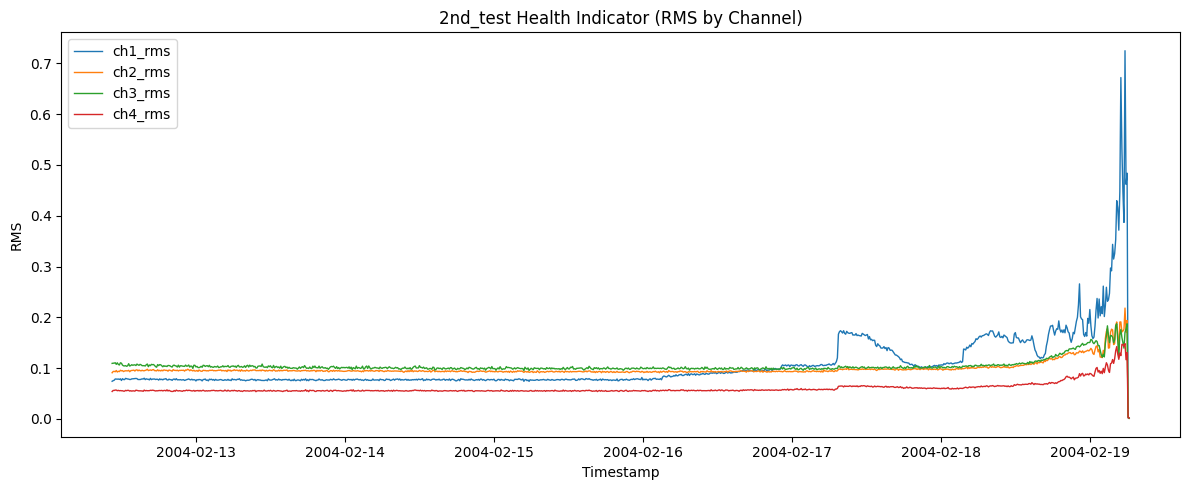

In [9]:
rms_cols = [col for col in hi_2nd_df.columns if col.endswith('_rms') and '_monotonic' not in col]

plt.figure(figsize=(12, 5))
for col in rms_cols:
    plt.plot(hi_2nd_df['timestamp'], hi_2nd_df[col], label=col, linewidth=1.0)

plt.title('2nd_test Health Indicator (RMS by Channel)')
plt.xlabel('Timestamp')
plt.ylabel('RMS')
plt.legend()
plt.tight_layout()
plt.show()



## Degradation Start Detection For 2nd Test

Use `ch3_rms` as the health indicator, then apply the paper-style healthy-reference sliding-window distance method.


In [10]:
hi_series = hi_2nd_df['ch1_rms'].to_numpy(dtype=float)
time_series = hi_2nd_df['timestamp']

healthy_window = 100
reference_window = hi_series[:healthy_window]

def window_distance(reference, current):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    return float(np.sqrt(np.sum((reference - current) ** 2)))

distance_rows = []
for start_idx in range(0, len(hi_series) - healthy_window + 1):
    end_idx = start_idx + healthy_window
    current_window = hi_series[start_idx:end_idx]
    dist = window_distance(reference_window, current_window)
    distance_rows.append(
        {
            'start_idx': start_idx,
            'end_idx': end_idx - 1,
            'start_time': time_series.iloc[start_idx],
            'end_time': time_series.iloc[end_idx - 1],
            'distance': dist,
        }
    )

distance_df = pd.DataFrame(distance_rows)
distance_df.head()



,start_idx,end_idx,start_time,end_time,distance
0,0,99,2004-02-12 10:32:39,2004-02-13 03:02:39,0.000000
1,1,100,2004-02-12 10:42:39,2004-02-13 03:12:39,0.014186
2,2,101,2004-02-12 10:52:39,2004-02-13 03:22:39,0.013070
3,3,102,2004-02-12 11:02:39,2004-02-13 03:32:39,0.015598
4,4,103,2004-02-12 11:12:39,2004-02-13 03:42:39,0.014717


In [11]:
baseline_slice = distance_df.iloc[:healthy_window].copy()
relative_threshold = baseline_slice['distance'].mean() + 8 * baseline_slice['distance'].std()
absolute_floor = 0.05
distance_threshold = max(relative_threshold, absolute_floor)

consecutive_k = 8
slope_window = 20
slope_threshold = 0.0001
degradation_row = None

for i in range(len(distance_df) - consecutive_k + 1):
    window = distance_df.iloc[i:i + consecutive_k]
    if not (window['distance'] > distance_threshold).all():
        continue

    candidate_row = window.iloc[0]
    end_idx = int(candidate_row['end_idx'])
    slope_start = max(0, end_idx - slope_window + 1)
    local_hi = hi_series[slope_start:end_idx + 1]
    local_slope = float(np.mean(np.diff(local_hi))) if len(local_hi) > 1 else 0.0

    if local_slope > slope_threshold:
        degradation_row = candidate_row.copy()
        degradation_row['local_slope'] = local_slope
        break

relative_threshold, distance_threshold, degradation_row


(np.float64(0.03243816804956384),
 0.05,
 start_idx                      462
 end_idx                        561
 start_time     2004-02-15 15:32:39
 end_time       2004-02-16 08:02:39
 distance                   0.05101
 local_slope               0.000184
 Name: 462, dtype: object)

In [12]:
if degradation_row is not None:
    degradation_idx = int(degradation_row['end_idx'])
    degradation_time = degradation_row['end_time'] if 'end_time' in degradation_row.index else time_series.iloc[degradation_idx]
else:
    degradation_idx = None
    degradation_time = None


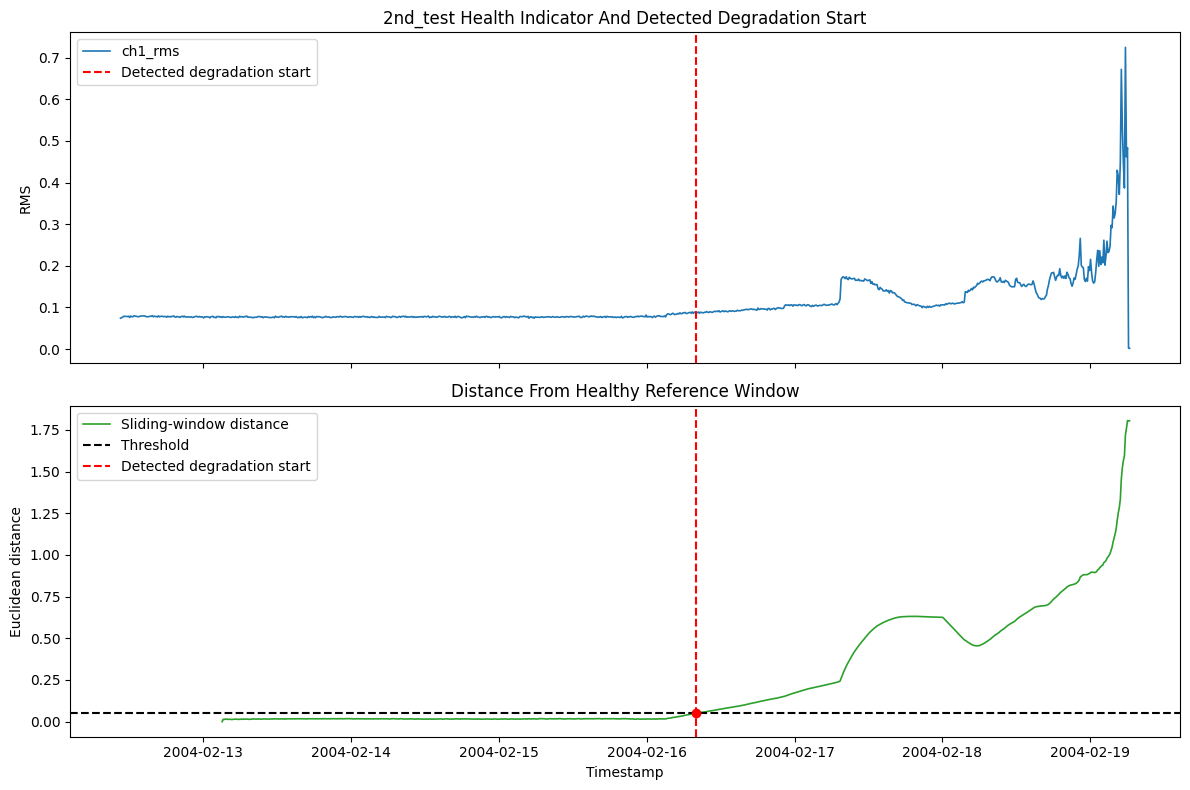

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time_series, hi_series, color='tab:blue', linewidth=1.2, label='ch1_rms')
if degradation_time is not None:
    axes[0].axvline(degradation_time, color='red', linestyle='--', label='Detected degradation start')
axes[0].set_title('2nd_test Health Indicator And Detected Degradation Start')
axes[0].set_ylabel('RMS')
axes[0].legend()

axes[1].plot(distance_df['end_time'], distance_df['distance'], color='tab:green', linewidth=1.2, label='Sliding-window distance')
axes[1].axhline(distance_threshold, color='black', linestyle='--', label='Threshold')
if degradation_time is not None:
    axes[1].axvline(degradation_time, color='red', linestyle='--', label='Detected degradation start')
axes[1].scatter([degradation_time], [degradation_row['distance']], color='red', zorder=3)
axes[1].set_title('Distance From Healthy Reference Window')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Euclidean distance')
axes[1].legend()

plt.tight_layout()
plt.show()



In [14]:
pd.DataFrame(
    {
        'healthy_window': [healthy_window],
        'distance_threshold': [distance_threshold],
        'degradation_idx': [degradation_idx],
        'degradation_time': [degradation_time],
    }
)


,healthy_window,distance_threshold,degradation_idx,degradation_time
0,100,0.05,561,2004-02-16 08:02:39


In [15]:
def fit_hybrid_model(history):
    history = np.asarray(history, dtype=float)
    history = np.maximum(history, 1e-8)
    t = np.arange(len(history), dtype=float)

    if len(history) < 5:
        return {
            'a': float(history[-1]),
            'b': 1e-6,
            'c': 0.0,
            'd': 0.0,
            'e': 0.0,
        }

    trend_history = np.maximum.accumulate(history)
    slope, intercept = np.polyfit(t, np.log(trend_history), 1)
    a = float(np.exp(intercept))
    b = float(max(slope, 1e-6))

    exp_part = a * np.exp(b * t)
    residual = history - exp_part
    poly_coef = np.polyfit(t, residual, 2)
    c, d, e = [float(v) for v in poly_coef]

    return {
        'a': a,
        'b': b,
        'c': c,
        'd': d,
        'e': e,
    }


def hybrid_model_predict(model, next_t):
    next_t = float(next_t)
    pred = (
        model['a'] * np.exp(model['b'] * next_t)
        + model['c'] * (next_t ** 2)
        + model['d'] * next_t
        + model['e']
    )
    return max(float(pred), 1e-8)


class StandardHMUPF:
    def __init__(self, num_particles=800, process_noise=0.003, measurement_noise=0.004, fit_window=100):
        self.num_particles = int(num_particles)
        self.process_noise = float(process_noise)
        self.measurement_noise = float(measurement_noise)
        self.fit_window = int(fit_window)
        self.particles = None
        self.weights = None

    def initialize(self, x0):
        self.particles = np.maximum(
            float(x0) + self.process_noise * np.random.randn(self.num_particles),
            1e-8,
        )
        self.weights = np.ones(self.num_particles, dtype=float) / self.num_particles

    def hm_predict_center(self, history):
        recent = np.asarray(history[-self.fit_window:], dtype=float)
        model = fit_hybrid_model(recent)
        return hybrid_model_predict(model, len(recent))

    def systematic_resample(self):
        n = self.num_particles
        positions = (np.random.rand() + np.arange(n)) / n
        cumulative_sum = np.cumsum(self.weights)
        cumulative_sum[-1] = 1.0
        indexes = np.searchsorted(cumulative_sum, positions)
        self.particles = self.particles[indexes]
        self.weights = np.ones(n, dtype=float) / n

    def update(self, y_obs, history):
        center = self.hm_predict_center(history)
        prior_var = max(self.process_noise ** 2, 1e-10)
        meas_var = max(self.measurement_noise ** 2, 1e-10)

        kalman_gain = prior_var / (prior_var + meas_var)
        proposal_mean = center + kalman_gain * (y_obs - center)
        proposal_var = max((1.0 - kalman_gain) * prior_var, 1e-10)

        self.particles = proposal_mean + np.sqrt(proposal_var) * np.random.randn(self.num_particles)
        self.particles = np.maximum(self.particles, 1e-8)

        residual = y_obs - self.particles
        likelihood = np.exp(-0.5 * (residual ** 2) / meas_var)
        self.weights = likelihood + 1e-12
        self.weights = self.weights / np.sum(self.weights)

        estimate = float(np.sum(self.particles * self.weights))
        self.systematic_resample()
        return estimate, center, proposal_mean


In [16]:
hm_upf = StandardHMUPF(
    num_particles=800,
    process_noise=0.003,
    measurement_noise=0.004,
    fit_window=healthy_window,
)

state_rows = []
state_history = [float(hi_series[degradation_idx])]
hm_upf.initialize(state_history[0])

state_rows.append(
    {
        'idx': int(degradation_idx),
        'timestamp': time_series.iloc[degradation_idx],
        'observed_hi': float(hi_series[degradation_idx]),
        'hm_center': float(hi_series[degradation_idx]),
        'proposal_mean': float(hi_series[degradation_idx]),
        'estimated_state': float(hi_series[degradation_idx]),
        'state_count_from_tsd': 1,
    }
)

for idx in range(degradation_idx + 1, len(hi_series)):
    y_obs = float(hi_series[idx])
    estimate, center, proposal_mean = hm_upf.update(y_obs=y_obs, history=state_history)
    state_history.append(estimate)
    state_rows.append(
        {
            'idx': int(idx),
            'timestamp': time_series.iloc[idx],
            'observed_hi': y_obs,
            'hm_center': float(center),
            'proposal_mean': float(proposal_mean),
            'estimated_state': float(estimate),
            'state_count_from_tsd': len(state_history),
        }
    )

state_2nd_df = pd.DataFrame(state_rows)
state_2nd_df.head()


,idx,timestamp,observed_hi,hm_center,proposal_mean,estimated_state,state_count_from_tsd
0,561,2004-02-16 08:02:39,0.087305,0.087305,0.087305,0.087305,1
1,562,2004-02-16 08:12:39,0.087479,0.087305,0.087368,0.087372,2
2,563,2004-02-16 08:22:39,0.088917,0.087373,0.087929,0.088175,3
3,564,2004-02-16 08:32:39,0.086065,0.088175,0.087416,0.087083,4
4,565,2004-02-16 08:42:39,0.088498,0.087084,0.087593,0.087855,5


In [17]:
L_min = 80
tsp_row = state_2nd_df[state_2nd_df['state_count_from_tsd'] >= L_min].iloc[0].copy()
tsp_idx = int(tsp_row['idx'])
tsp_time = tsp_row['timestamp']

pd.DataFrame(
    {
        'TSD_idx': [degradation_idx],
        'TSD_time': [degradation_time],
        'L_min': [L_min],
        'TSP_idx': [tsp_idx],
        'TSP_time': [tsp_time],
    }
)


,TSD_idx,TSD_time,L_min,TSP_idx,TSP_time
0,561,2004-02-16 08:02:39,80,640,2004-02-16 21:12:39


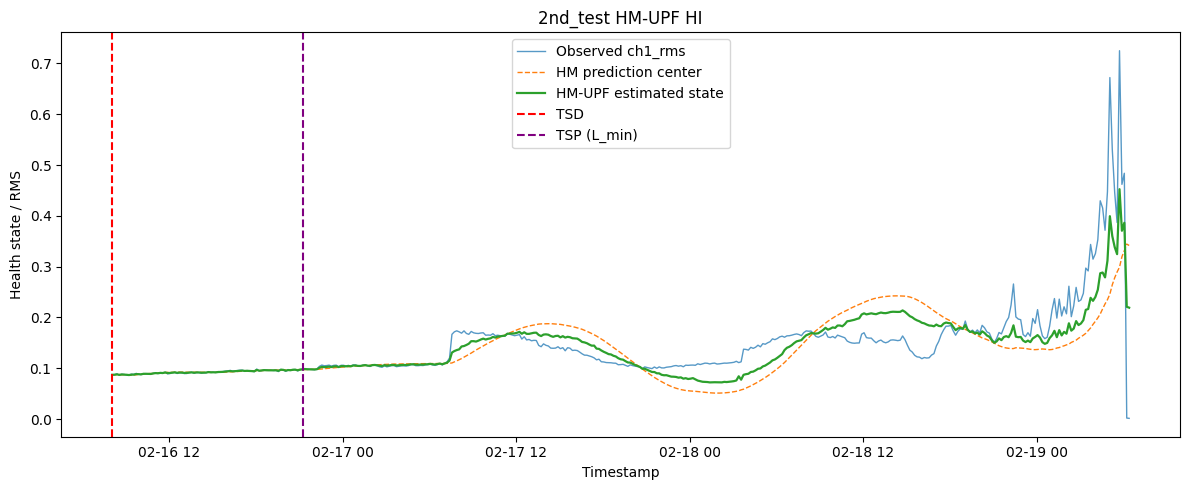

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(state_2nd_df['timestamp'], state_2nd_df['observed_hi'], label='Observed ch1_rms', linewidth=1.0, alpha=0.75)
plt.plot(state_2nd_df['timestamp'], state_2nd_df['hm_center'], label='HM prediction center', linewidth=1.0, linestyle='--')
plt.plot(state_2nd_df['timestamp'], state_2nd_df['estimated_state'], label='HM-UPF estimated state', linewidth=1.6)
plt.axvline(degradation_time, color='red', linestyle='--', label='TSD')
plt.axvline(tsp_time, color='purple', linestyle='--', label='TSP (L_min)')
plt.title('2nd_test HM-UPF HI')
plt.xlabel('Timestamp')
plt.ylabel('Health state / RMS')
plt.legend()
plt.tight_layout()
plt.show()



In [19]:
import math


def gaussian_pdf_scalar(x, mean, var):
    var = max(float(var), 1e-12)
    return math.exp(-0.5 * ((float(x) - float(mean)) ** 2) / var) / math.sqrt(2.0 * math.pi * var)


def q_function(z):
    return 0.5 * math.erfc(float(z) / math.sqrt(2.0))


def gaussian_pdf_multivariate(x, mean, cov):
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    cov = np.nan_to_num(cov, nan=0.0, posinf=1e6, neginf=-1e6)
    cov += 1e-8 * np.eye(cov.shape[0])

    diff = x - mean
    try:
        sign, logdet = np.linalg.slogdet(cov)
        if sign <= 0:
            cov = cov + 1e-6 * np.eye(cov.shape[0])
            sign, logdet = np.linalg.slogdet(cov)
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov = cov + 1e-4 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)
        inv_cov = np.linalg.inv(cov)

    quad = float(diff.T @ inv_cov @ diff)
    dim = x.shape[0]
    log_norm = -0.5 * (dim * math.log(2.0 * math.pi) + logdet + quad)
    return math.exp(max(log_norm, -700.0))


def fit_exponential_history(history):
    history = np.asarray(history, dtype=float)
    history = np.maximum.accumulate(np.maximum(history, 1e-8))
    history = np.clip(history, 1e-8, 1e3)
    t = np.arange(len(history), dtype=float)

    if len(history) < 2:
        return float(history[-1]), 1e-4

    slope, intercept = np.polyfit(t, np.log(history), 1)
    a0 = float(np.clip(np.exp(intercept), 1e-8, 1e3))
    b0 = float(np.clip(max(slope, 1e-5), 1e-5, 0.08))
    return a0, b0


def finite_difference(values, dt=1.0):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return np.zeros(0, dtype=float)
    return np.diff(values) / max(float(dt), 1e-12)


def monotonic_increase_penalty(values, dt=1.0, min_rate=0.0):
    deriv = finite_difference(values, dt=dt)
    if deriv.size == 0:
        return 0.0
    violation = np.maximum(0.0, float(min_rate) - deriv)
    return float(np.mean(violation ** 2))


def rul_decrease_penalty(values, dt=1.0):
    deriv = finite_difference(values, dt=dt)
    if deriv.size == 0:
        return 0.0
    violation = np.maximum(0.0, deriv)
    return float(np.mean(violation ** 2))


def compute_rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


def compute_cra(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid_mask = actual > 0
    if not np.any(valid_mask):
        return float('nan')
    actual = actual[valid_mask]
    predicted = predicted[valid_mask]
    ra = 1.0 - np.abs(actual - predicted) / actual
    ra = np.clip(ra, 0.0, 1.0)
    weights = actual / actual.sum()
    return float(np.sum(weights * ra))


def build_failure_threshold(state_df, mode='tail_quantile', tail_quantile=0.97, lambda_ft=6.0):
    state_series = state_df['estimated_state'].astype(float).copy()
    state_series = state_series.replace([np.inf, -np.inf], np.nan).dropna()
    state_series = state_series[state_series > 0]

    if mode == 'healthy_stat':
        healthy_ref = np.asarray(hi_series[:degradation_idx], dtype=float)
        healthy_ref = healthy_ref[np.isfinite(healthy_ref)]
        healthy_ref = healthy_ref[healthy_ref > 0]
        threshold = float(healthy_ref.mean() + lambda_ft * healthy_ref.std(ddof=0))
    elif mode == 'tail_quantile':
        threshold = float(np.quantile(state_series.iloc[:-1], tail_quantile))
    else:
        raise ValueError('Unsupported failure-threshold mode.')

    return max(threshold, 1e-8)


class FullSingleStreamEMUPF:
    def __init__(
        self,
        num_particles=100,
        process_noise_x=0.003,
        process_noise_b=2e-4,
        measurement_noise=0.004,
        alpha=0.35,
        beta=2.0,
        kappa=0.0,
        ess_ratio=0.5,
        time_step=1.0,
        lambda_physics=8.0,
        lambda_rul=4.0,
        min_health_rate=0.0,
    ):
        self.num_particles = int(num_particles)
        self.process_noise_x = float(process_noise_x)
        self.process_noise_b = float(process_noise_b)
        self.measurement_noise = float(measurement_noise)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.kappa = float(kappa)
        self.ess_ratio = float(ess_ratio)
        self.time_step = float(time_step)
        self.lambda_physics = float(lambda_physics)
        self.lambda_rul = float(lambda_rul)
        self.min_health_rate = float(min_health_rate)
        self.state_dim = 2  # [x, b]
        self.meas_dim = 1
        self.Q = np.diag([self.process_noise_x ** 2, self.process_noise_b ** 2])
        self.R = np.array([[self.measurement_noise ** 2]], dtype=float)

    def transition_fn(self, state):
        x, b = float(state[0]), float(state[1])
        x = min(max(x, 1e-8), 1e3)
        b = min(max(b, 1e-8), 0.08)
        growth = math.exp(min(b, 0.08))
        x_next = min(max(x * growth, 1e-8), 1e3)
        b_next = min(max(b, 1e-8), 0.08)
        return np.array([x_next, b_next], dtype=float)

    def measurement_fn(self, state):
        return np.array([max(float(state[0]), 1e-8)], dtype=float)

    def sigma_points(self, mean, cov):
        n = self.state_dim
        mean = np.asarray(mean, dtype=float)
        mean = np.nan_to_num(mean, nan=1e-8, posinf=1e6, neginf=1e-8)
        cov = self.stabilize_covariance(cov, min_diag=1e-8)
        jitter = 1e-8

        lam = self.alpha ** 2 * (n + self.kappa) - n
        scale = max(n + lam, 1e-8)

        while True:
            try:
                chol = np.linalg.cholesky(scale * (cov + jitter * np.eye(n)))
                break
            except np.linalg.LinAlgError:
                jitter *= 10.0
                cov = self.stabilize_covariance(cov + jitter * np.eye(n), min_diag=1e-8)
                if jitter > 1e-1:
                    cov = self.stabilize_covariance(np.diag(np.maximum(np.diag(cov), 1e-6)), min_diag=1e-6)
                    chol = np.linalg.cholesky(scale * cov)
                    break

        points = [mean]
        for i in range(n):
            points.append(mean + chol[:, i])
            points.append(mean - chol[:, i])
        points = np.asarray(points, dtype=float)

        wm = np.full(2 * n + 1, 1.0 / (2.0 * scale), dtype=float)
        wc = np.full(2 * n + 1, 1.0 / (2.0 * scale), dtype=float)
        wm[0] = lam / scale
        wc[0] = lam / scale + (1.0 - self.alpha ** 2 + self.beta)
        return points, wm, wc

    def unscented_predict(self, mean, cov):
        sigma_pts, wm, wc = self.sigma_points(mean, cov)
        propagated = np.array([self.transition_fn(p) for p in sigma_pts], dtype=float)
        propagated = np.nan_to_num(propagated, nan=1e-8, posinf=1e6, neginf=1e-8)
        mean_pred = np.sum(wm[:, None] * propagated, axis=0)
        mean_pred = np.nan_to_num(mean_pred, nan=1e-8, posinf=1e6, neginf=1e-8)
        diff = propagated - mean_pred
        cov_pred = self.Q.copy()
        for i in range(len(propagated)):
            cov_pred += wc[i] * np.outer(diff[i], diff[i])
        cov_pred = self.stabilize_covariance(cov_pred, min_diag=1e-8)
        return mean_pred, cov_pred, propagated, wm, wc

    def unscented_update(self, mean_pred, cov_pred, observation):
        sigma_pts, wm, wc = self.sigma_points(mean_pred, cov_pred)
        meas_sigma = np.array([self.measurement_fn(p) for p in sigma_pts], dtype=float)
        meas_sigma = np.nan_to_num(meas_sigma, nan=1e-8, posinf=1e6, neginf=1e-8)
        y_pred = np.sum(wm[:, None] * meas_sigma, axis=0)
        y_pred = np.nan_to_num(y_pred, nan=1e-8, posinf=1e6, neginf=1e-8)

        dy = meas_sigma - y_pred
        dx = sigma_pts - mean_pred

        S = self.R.copy()
        Cxy = np.zeros((self.state_dim, self.meas_dim), dtype=float)
        for i in range(len(sigma_pts)):
            S += wc[i] * np.outer(dy[i], dy[i])
            Cxy += wc[i] * np.outer(dx[i], dy[i])

        S = np.array([[max(float(S[0, 0]), 1e-8)]], dtype=float)
        K = Cxy @ np.linalg.inv(S)
        innovation = np.array([float(observation)], dtype=float) - y_pred
        mean_post = mean_pred + (K @ innovation)
        mean_post = np.nan_to_num(mean_post, nan=1e-8, posinf=1e6, neginf=1e-8)
        mean_post[0] = max(float(mean_post[0]), 1e-8)
        mean_post[1] = max(float(mean_post[1]), 1e-8)
        cov_post = cov_pred - K @ S @ K.T
        cov_post = self.stabilize_covariance(cov_post, min_diag=1e-8)
        return mean_post, cov_post, float(y_pred[0]), float(S[0, 0])

    def stabilize_covariance(self, cov, min_diag=1e-10):
        cov = np.asarray(cov, dtype=float)
        cov = np.nan_to_num(cov, nan=0.0, posinf=1e6, neginf=-1e6)
        cov = 0.5 * (cov + cov.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvals = np.clip(eigvals, min_diag, None)
        cov = eigvecs @ np.diag(eigvals) @ eigvecs.T
        cov = 0.5 * (cov + cov.T)
        cov += min_diag * np.eye(cov.shape[0])
        return cov

    def sample_gaussian(self, mean, cov):
        mean = np.asarray(mean, dtype=float)
        mean = np.nan_to_num(mean, nan=1e-8, posinf=1e6, neginf=1e-8)
        cov = self.stabilize_covariance(cov)

        for jitter_scale in [0.0, 1e-10, 1e-8, 1e-6, 1e-4]:
            try:
                sample = np.random.multivariate_normal(mean, cov + jitter_scale * np.eye(len(mean)))
                sample = np.asarray(sample, dtype=float)
                sample = np.nan_to_num(sample, nan=1e-8, posinf=1e6, neginf=1e-8)
                sample[0] = max(float(sample[0]), 1e-8)
                sample[1] = max(float(sample[1]), 1e-8)
                return sample
            except np.linalg.LinAlgError:
                continue

        fallback = mean.copy()
        fallback[0] = max(float(fallback[0]), 1e-8)
        fallback[1] = max(float(fallback[1]), 1e-8)
        return fallback

    def initialize_particles(self, history):
        history = np.asarray(history, dtype=float)
        a0, b0 = fit_exponential_history(history)
        x0 = float(np.clip(max(history[0], 1e-8), 1e-8, 1e3))
        means = np.zeros((self.num_particles, self.state_dim), dtype=float)
        means[:, 0] = np.clip(x0 + self.process_noise_x * np.random.randn(self.num_particles), 1e-8, 1e3)
        means[:, 1] = np.clip(b0 + self.process_noise_b * np.random.randn(self.num_particles), 1e-8, 0.08)
        states = means.copy()

        cov0 = np.diag([
            max(self.process_noise_x ** 2, 1e-8),
            max((5.0 * self.process_noise_b) ** 2, 1e-10),
        ])
        covs = np.repeat(cov0[None, :, :], self.num_particles, axis=0)
        weights = np.ones(self.num_particles, dtype=float) / self.num_particles
        return states, means, covs, weights

    def systematic_resample(self, states, means, covs, weights):
        n = len(weights)
        positions = (np.random.rand() + np.arange(n)) / n
        cumulative = np.cumsum(weights)
        cumulative[-1] = 1.0
        indexes = np.searchsorted(cumulative, positions)
        states = states[indexes].copy()
        means = means[indexes].copy()
        covs = covs[indexes].copy()
        weights = np.ones(n, dtype=float) / n
        return states, means, covs, weights

    def filter_history(self, history):
        history = np.asarray(history, dtype=float)
        states, means, covs, weights = self.initialize_particles(history)
        filtered_records = []

        for step_idx, y in enumerate(history):
            new_states = np.zeros_like(states)
            new_means = np.zeros_like(means)
            new_covs = np.zeros_like(covs)
            new_weights = np.zeros_like(weights)

            for i in range(self.num_particles):
                mean_prev = means[i]
                cov_prev = covs[i]

                if step_idx == 0:
                    mean_pred = mean_prev.copy()
                    cov_pred = cov_prev.copy()
                else:
                    mean_pred, cov_pred, _, _, _ = self.unscented_predict(mean_prev, cov_prev)

                mean_post, cov_post, y_pred, s_var = self.unscented_update(mean_pred, cov_pred, y)
                sample = self.sample_gaussian(mean_post, cov_post)

                new_states[i] = sample
                new_means[i] = mean_post
                new_covs[i] = cov_post
                sampled_obs = float(self.measurement_fn(sample)[0])

                likelihood = gaussian_pdf_scalar(y, sampled_obs, max(self.measurement_noise ** 2, 1e-10))
                prior_density = gaussian_pdf_multivariate(sample, mean_pred, cov_pred)
                proposal_density = gaussian_pdf_multivariate(sample, mean_post, cov_post)
                proposal_density = max(proposal_density, 1e-300)

                prev_x = float(history[max(step_idx - 1, 0)]) if step_idx > 0 else float(history[0])
                phys_penalty = monotonic_increase_penalty([prev_x, float(sample[0])], dt=self.time_step, min_rate=self.min_health_rate)
                phys_factor = math.exp(-self.lambda_physics * phys_penalty)
                new_weights[i] = weights[i] * likelihood * prior_density / proposal_density * phys_factor

            new_weights = new_weights + 1e-300
            new_weights = new_weights / new_weights.sum()

            ess = 1.0 / np.sum(new_weights ** 2)
            states, means, covs, weights = new_states, new_means, new_covs, new_weights
            if ess < self.ess_ratio * self.num_particles:
                states, means, covs, weights = self.systematic_resample(states, means, covs, weights)

            filtered_x = float(np.sum(weights * states[:, 0]))
            filtered_b = float(np.sum(weights * states[:, 1]))
            filtered_records.append(
                {
                    'step': int(step_idx),
                    'obs': float(y),
                    'filtered_x': filtered_x,
                    'filtered_b': filtered_b,
                }
            )

        posterior = {
            'states': states.copy(),
            'means': means.copy(),
            'covs': covs.copy(),
            'weights': weights.copy(),
            'filtered_df': pd.DataFrame(filtered_records),
        }
        return posterior

    def predict_failure_distribution(self, posterior, failure_threshold, max_horizon=300):
        states = posterior.get('states', posterior['means']).copy()
        means = posterior['means'].copy()
        covs = posterior['covs'].copy()
        weights = posterior['weights'].copy()

        records = []
        survival_prob = 1.0
        prev_mean = float(posterior['filtered_df'].iloc[-1]['filtered_x'])

        for horizon in range(1, int(max_horizon) + 1):
            phys_factors = np.ones_like(weights)
            new_states = np.zeros_like(states)
            new_means = np.zeros_like(means)
            new_covs = np.zeros_like(covs)
            for i in range(self.num_particles):
                prev_particle_x = float(states[i, 0])
                mean_pred, cov_pred, _, _, _ = self.unscented_predict(means[i], covs[i])
                sample = self.sample_gaussian(mean_pred, cov_pred)
                new_states[i] = sample
                new_means[i] = mean_pred
                new_covs[i] = cov_pred

                phys_penalty = monotonic_increase_penalty([prev_particle_x, float(sample[0])], dt=self.time_step, min_rate=self.min_health_rate)
                phys_factors[i] = math.exp(-self.lambda_physics * phys_penalty)

            states, means, covs = new_states, new_means, new_covs
            weights = weights * phys_factors
            weights = weights + 1e-300
            weights = weights / np.sum(weights)

            x_particles = np.clip(states[:, 0], 1e-8, 1e3)
            pred_mean = float(np.clip(np.sum(weights * x_particles), 1e-8, 1e3))
            pred_std = float(np.sqrt(np.sum(weights * (x_particles - pred_mean) ** 2) + 1e-12))
            pred_std = min(max(pred_std, 1e-8), 1e2)
            z_value = (float(failure_threshold) - pred_mean) / max(pred_std, 1e-8)
            cond_fp = q_function(z_value)
            health_penalty = monotonic_increase_penalty([prev_mean, pred_mean], dt=self.time_step, min_rate=self.min_health_rate)
            cond_fp = cond_fp * math.exp(-self.lambda_physics * health_penalty)
            db_fp = survival_prob * cond_fp

            records.append(
                {
                    'horizon': int(horizon),
                    'pred_mean': pred_mean,
                    'pred_std': pred_std,
                    'conditional_fp': cond_fp,
                    'survival_before_step': survival_prob,
                    'db_failure_probability': db_fp,
                }
            )

            survival_prob *= max(1.0 - cond_fp, 1e-12)
            prev_mean = pred_mean
            if survival_prob < 1e-10 and horizon >= 10:
                break

        fp_df = pd.DataFrame(records)
        max_row = fp_df.loc[fp_df['db_failure_probability'].idxmax()].copy()
        return fp_df, int(max_row['horizon']), max_row


In [20]:
ft_mode = 'healthy_stat'
ft_tail_quantile = None
ft_lambda = 12.0
failure_margin = 0.05
base_failure_threshold = build_failure_threshold(
    state_2nd_df,
    mode=ft_mode,
    tail_quantile=0.97,
    lambda_ft=ft_lambda,
)
tsp_state = float(state_2nd_df.loc[state_2nd_df['idx'] == tsp_idx, 'estimated_state'].iloc[0])
failure_threshold = max(
    float(base_failure_threshold),
    float(tsp_state + failure_margin),
)

failure_cross_df = state_2nd_df[state_2nd_df['estimated_state'] >= failure_threshold].copy()
actual_failure_idx = int(failure_cross_df.iloc[0]['idx']) if len(failure_cross_df) > 0 else int(state_2nd_df.iloc[-2]['idx'])
actual_failure_time = time_series.iloc[actual_failure_idx]

em_upf = FullSingleStreamEMUPF(
    num_particles=100,
    process_noise_x=0.003,
    process_noise_b=2e-4,
    measurement_noise=0.004,
    alpha=0.35,
    beta=2.0,
    kappa=0.0,
    ess_ratio=0.5,
    time_step=1.0,
    lambda_physics=8.0,
    lambda_rul=4.0,
    min_health_rate=0.0,
)

prediction_rows = []
db_curves = {}

monitor_df = state_2nd_df[(state_2nd_df['idx'] >= tsp_idx) & (state_2nd_df['idx'] < actual_failure_idx)].copy()

for _, row in monitor_df.iterrows():
    current_idx = int(row['idx'])
    current_time = row['timestamp']
    history_df = state_2nd_df[state_2nd_df['idx'] <= current_idx].copy()
    history = history_df['estimated_state'].astype(float).to_numpy()

    posterior = em_upf.filter_history(history)
    max_horizon = max(actual_failure_idx - current_idx + 50, 80)
    fp_df, pred_horizon, max_fp_row = em_upf.predict_failure_distribution(
        posterior,
        failure_threshold=failure_threshold,
        max_horizon=max_horizon,
    )

    predicted_failure_idx = current_idx + pred_horizon
    predicted_rul = pred_horizon
    actual_rul = actual_failure_idx - current_idx

    prediction_rows.append(
        {
            'current_idx': current_idx,
            'current_time': current_time,
            'history_len': len(history),
            'predicted_failure_idx': predicted_failure_idx,
            'predicted_rul': predicted_rul,
            'actual_rul': actual_rul,
            'max_db_failure_probability': float(max_fp_row['db_failure_probability']),
            'pred_mean_at_peak': float(max_fp_row['pred_mean']),
            'pred_std_at_peak': float(max_fp_row['pred_std']),
            'failure_threshold': float(failure_threshold),
        }
    )

    if current_idx == tsp_idx:
        db_curves['tsp'] = fp_df.copy()

rul_pred_df = pd.DataFrame(prediction_rows)
if not rul_pred_df.empty:
    rul_physics_penalty = rul_decrease_penalty(rul_pred_df['predicted_rul'].to_numpy(dtype=float), dt=1.0)
    rmse_value = compute_rmse(rul_pred_df['actual_rul'], rul_pred_df['predicted_rul'])
    cra_value = compute_cra(rul_pred_df['actual_rul'], rul_pred_df['predicted_rul'])
else:
    rul_physics_penalty = float('nan')
    rmse_value = float('nan')
    cra_value = float('nan')

pd.DataFrame(
    {
        'ft_mode': [ft_mode],
        'base_failure_threshold': [base_failure_threshold],
        'tsp_state': [tsp_state],
        'failure_margin': [failure_margin],
        'failure_threshold': [failure_threshold],
        'actual_failure_idx': [actual_failure_idx],
        'actual_failure_time': [actual_failure_time],
        'rmse': [rmse_value],
        'cra': [cra_value],
        'rul_physics_penalty': [rul_physics_penalty],
    }
)


,ft_mode,base_failure_threshold,tsp_state,failure_margin,failure_threshold,actual_failure_idx,actual_failure_time,rmse,cra,rul_physics_penalty
0,healthy_stat,0.103694,0.097853,0.05,0.147853,709,2004-02-17 08:42:39,14.248824,0.693168,12.338235


In [21]:
pd.DataFrame(
    {
        'TSD_idx': [degradation_idx],
        'TSD_time': [degradation_time],
        'TSP_idx': [tsp_idx],
        'TSP_time': [tsp_time],
        'actual_failure_idx': [actual_failure_idx],
        'actual_failure_time': [actual_failure_time],
        'failure_threshold': [failure_threshold],
        'RMSE': [rmse_value],
        'CRA': [cra_value],
    }
)


,TSD_idx,TSD_time,TSP_idx,TSP_time,actual_failure_idx,actual_failure_time,failure_threshold,RMSE,CRA
0,561,2004-02-16 08:02:39,640,2004-02-16 21:12:39,709,2004-02-17 08:42:39,0.147853,14.248824,0.693168


In [22]:
healthy_ref = np.asarray(hi_series[:degradation_idx], dtype=float)
healthy_ref = healthy_ref[np.isfinite(healthy_ref)]
healthy_ref = healthy_ref[healthy_ref > 0]
mu_healthy = float(np.mean(healthy_ref))
sigma_healthy = float(np.std(healthy_ref, ddof=0))
tsp_state = float(state_2nd_df.loc[state_2nd_df['idx'] == tsp_idx, 'estimated_state'].iloc[0])
state_at_failure = float(state_2nd_df.loc[state_2nd_df['idx'] == actual_failure_idx, 'estimated_state'].iloc[0])
threshold_gap_from_tsp = float(failure_threshold - tsp_state)

pd.DataFrame(
    {
        'mu_healthy': [mu_healthy],
        'sigma_healthy': [sigma_healthy],
        'lambda_ft': [ft_lambda],
        'base_failure_threshold': [base_failure_threshold],
        'tsp_state': [tsp_state],
        'failure_margin': [failure_margin],
        'failure_threshold': [failure_threshold],
        'state_at_failure': [state_at_failure],
        'threshold_gap_from_tsp': [threshold_gap_from_tsp],
        'degradation_idx': [degradation_idx],
        'tsp_idx': [tsp_idx],
        'actual_failure_idx': [actual_failure_idx],
        'actual_failure_time': [actual_failure_time],
    }
)


,mu_healthy,sigma_healthy,lambda_ft,base_failure_threshold,tsp_state,failure_margin,failure_threshold,state_at_failure,threshold_gap_from_tsp,degradation_idx,tsp_idx,actual_failure_idx,actual_failure_time
0,0.077691,0.002167,12.0,0.103694,0.097853,0.05,0.147853,0.148419,0.05,561,640,709,2004-02-17 08:42:39


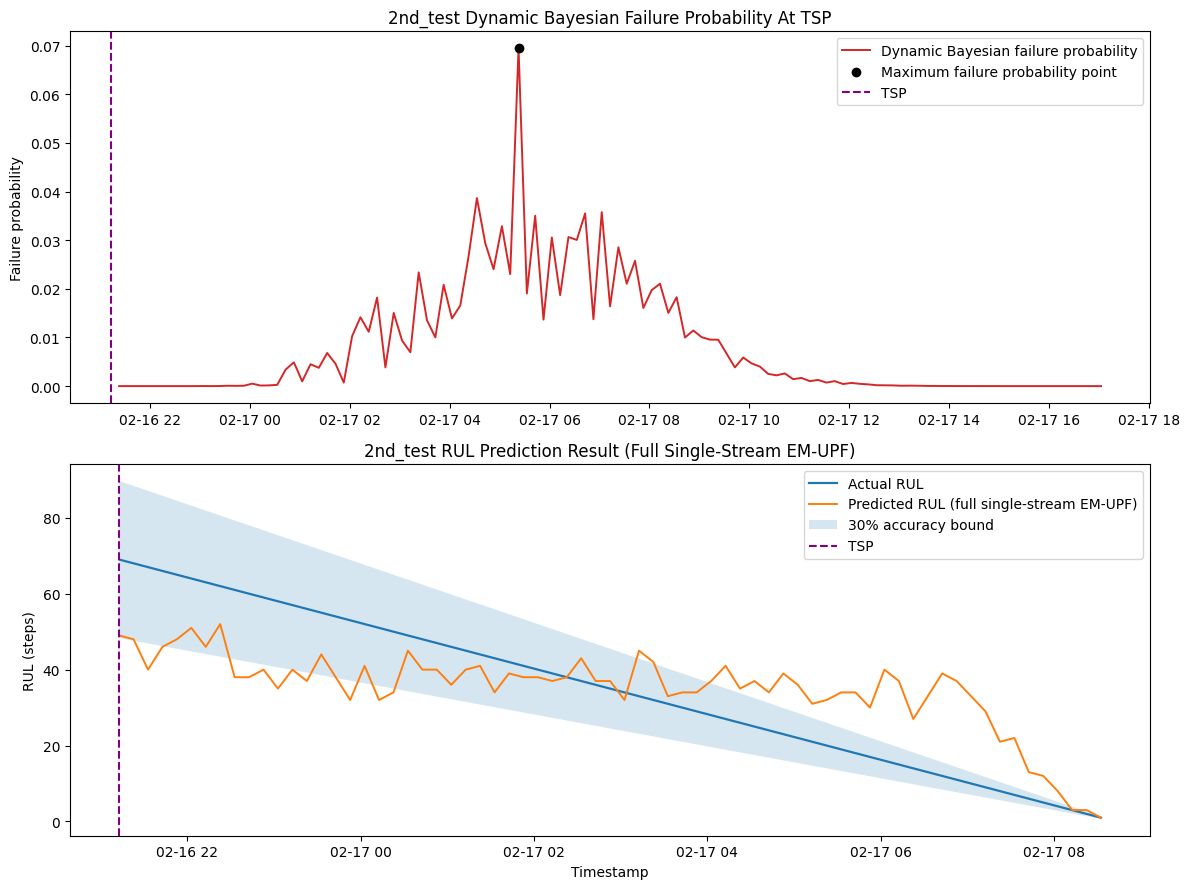

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

fp_plot_df = db_curves['tsp'].copy()
fp_plot_df['future_time'] = [time_series.iloc[min(tsp_idx + h, len(time_series) - 1)] for h in fp_plot_df['horizon']]
peak_row = fp_plot_df.loc[fp_plot_df['db_failure_probability'].idxmax()].copy()
peak_time = peak_row['future_time']

axes[0].plot(fp_plot_df['future_time'], fp_plot_df['db_failure_probability'], color='tab:red', linewidth=1.4, label='Dynamic Bayesian failure probability')
axes[0].scatter([peak_time], [peak_row['db_failure_probability']], color='black', zorder=3, label='Maximum failure probability point')
axes[0].axvline(tsp_time, color='purple', linestyle='--', label='TSP')
axes[0].set_title('2nd_test Dynamic Bayesian Failure Probability At TSP')
axes[0].set_ylabel('Failure probability')
axes[0].legend()

rul_plot_df = rul_pred_df.copy()
upper_bound = rul_plot_df['actual_rul'] * 1.3
lower_bound = rul_plot_df['actual_rul'] * 0.7

axes[1].plot(rul_plot_df['current_time'], rul_plot_df['actual_rul'], linewidth=1.6, label='Actual RUL')
axes[1].plot(rul_plot_df['current_time'], rul_plot_df['predicted_rul'], linewidth=1.4, label='Predicted RUL (full single-stream EM-UPF)')
axes[1].fill_between(rul_plot_df['current_time'], lower_bound, upper_bound, alpha=0.18, label='30% accuracy bound')
axes[1].axvline(tsp_time, color='purple', linestyle='--', label='TSP')
axes[1].set_title('2nd_test RUL Prediction Result (Full Single-Stream EM-UPF)')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('RUL (steps)')
axes[1].legend()

plt.tight_layout()
plt.show()

